In [ ]:
# Support Vector Machines (SVM)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [14]:
# Load Data
# SVM is distance/margin-based, so feature scaling is mandatory.

def load_data():
    df = pd.read_csv('titanic_cleaned.csv')
    y = df['survived']
    X = pd.get_dummies(df.drop('survived', axis=1), dtype=float)
    target_names = ['Not Survived', 'Survived']
    return X, y, target_names

X, y, target_names = load_data()

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")
print(f"Target names: {target_names}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Shape of X: (673, 23)
Shape of y: (673,)
Target names: ['Not Survived', 'Survived']


In [12]:
# Baseline: Linear Kernel

svm_linear = SVC(kernel="linear", random_state=42)
svm_linear.fit(X_train_scaled, y_train)
pred_linear = svm_linear.predict(X_test_scaled)
acc_linear = accuracy_score(y_test, pred_linear)
print("Linear Kernel Accuracy:", acc_linear)
print("Number of support vectors per class:", svm_linear.n_support_)

Linear Kernel Accuracy: 1.0
Number of support vectors per class: [ 2 11 10]


In [13]:
# RBF Kernel (default, non-linear)

svm_rbf = SVC(kernel="rbf", random_state=42)
svm_rbf.fit(X_train_scaled, y_train)
pred_rbf = svm_rbf.predict(X_test_scaled)
acc_rbf = accuracy_score(y_test, pred_rbf)
print("RBF Kernel Accuracy:", acc_rbf)
print("Number of support vectors per class:", svm_rbf.n_support_)

RBF Kernel Accuracy: 0.9666666666666667
Number of support vectors per class: [10 18 19]


In [5]:
# Polynomial Kernel

svm_poly = SVC(kernel="poly", degree=3, random_state=42)
svm_poly.fit(X_train_scaled, y_train)
pred_poly = svm_poly.predict(X_test_scaled)
acc_poly = accuracy_score(y_test, pred_poly)
print("Poly Kernel Accuracy:", acc_poly)

Poly Kernel Accuracy: 0.9


In [6]:
# Kernel Comparison Table

comparison = pd.DataFrame({
    "Kernel": ["Linear", "RBF", "Polynomial (deg=3)"],
    "Accuracy": [acc_linear, acc_rbf, acc_poly]
}).sort_values("Accuracy", ascending=False)
comparison

,Kernel,Accuracy
0,Linear,1.000000
1,RBF,0.966667
2,Polynomial (deg=3),0.900000


In [7]:
# Tune C and gamma (GridSearchCV)

param_grid = {
    "kernel": ["linear", "rbf", "poly"],
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.01, 0.1, 1]
}

grid = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid.fit(X_train_scaled, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

best_svm = grid.best_estimator_
best_pred = best_svm.predict(X_test_scaled)
print("Tuned SVM Test Accuracy:", accuracy_score(y_test, best_pred))
print(classification_report(y_test, best_pred, target_names=target_names))

Best Params: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Best CV Accuracy: 0.9833333333333332
Tuned SVM Test Accuracy: 0.9666666666666667
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



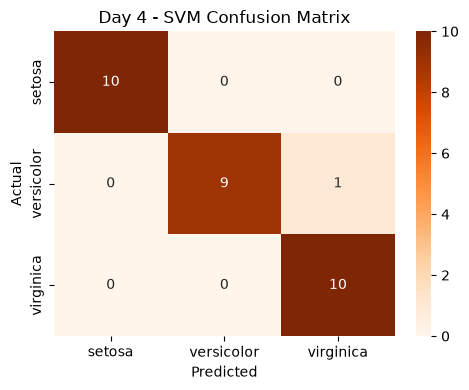

In [8]:
#  Confusion Matrix (Tuned SVM)

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Day 4 - SVM Confusion Matrix")
plt.tight_layout()
plt.show()

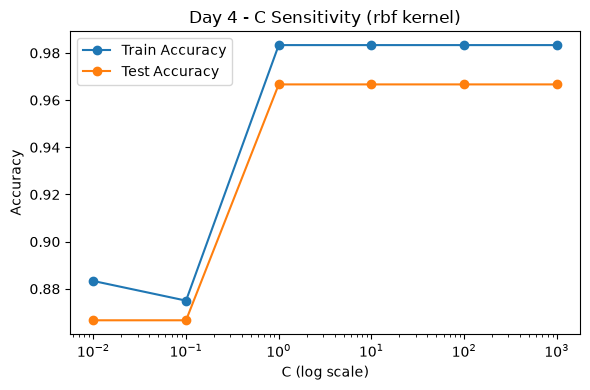

In [9]:
# C Sensitivity Check

C_values = [0.01, 0.1, 1, 10, 100, 1000]
train_acc, test_acc = [], []
best_kernel = grid.best_params_["kernel"]
best_gamma = grid.best_params_.get("gamma", "scale")

for c in C_values:
    clf = SVC(kernel=best_kernel, C=c, gamma=best_gamma, random_state=42)
    clf.fit(X_train_scaled, y_train)
    train_acc.append(clf.score(X_train_scaled, y_train))
    test_acc.append(clf.score(X_test_scaled, y_test))

plt.figure(figsize=(6, 4))
plt.plot(C_values, train_acc, marker="o", label="Train Accuracy")
plt.plot(C_values, test_acc, marker="o", label="Test Accuracy")
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("Accuracy")
plt.title(f"Day 4 - C Sensitivity ({best_kernel} kernel)")
plt.legend()
plt.tight_layout()
plt.show()

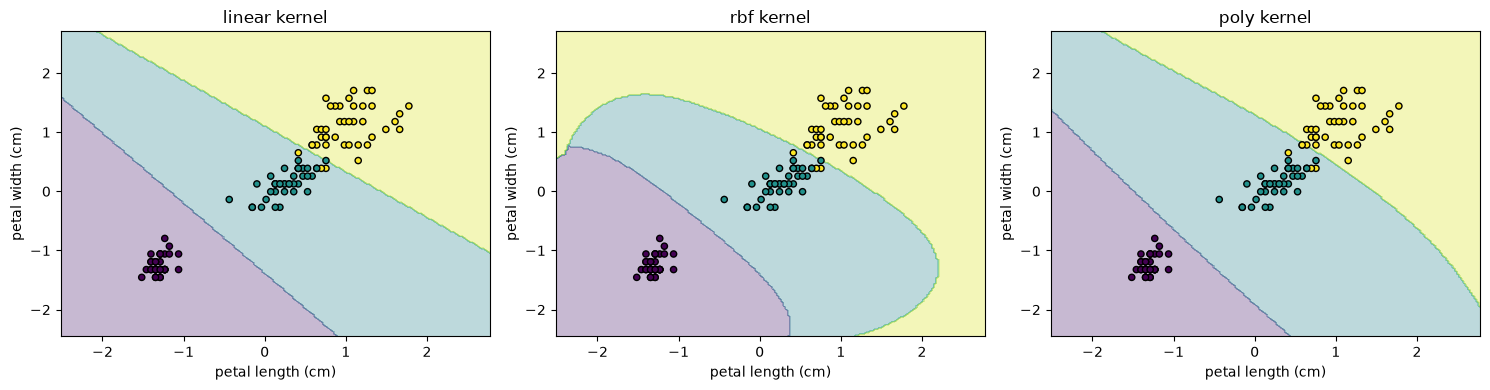

In [ ]:
# Decision Boundary Visualization (2D, top-2 numeric features)
# Using age and fare gives a simple 2D projection for visual intuition on Titanic.

top2 = ["age", "fare"]
X_train_2d = scaler.fit_transform(X_train[top2])
X_test_2d = scaler.transform(X_test[top2])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
kernels = ["linear", "rbf", "poly"]

for ax, kernel in zip(axes, kernels):
    clf = SVC(kernel=kernel, C=1, random_state=42)
    clf.fit(X_train_2d, y_train)

    xx, yy = np.meshgrid(
        np.linspace(X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1, 200),
        np.linspace(X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1, 200)
    )
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")
    ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap="viridis", edgecolors="k", s=20)
    ax.set_title(f"{kernel} kernel")
    ax.set_xlabel(top2[0])
    ax.set_ylabel(top2[1])

plt.tight_layout()
plt.show()